In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

In [223]:
centriods = [(-5,5),(2,3),(4,6)]
std = [1,1,1]

X,y = make_blobs(n_samples=200,n_features=2,centers=centriods,cluster_std=std,random_state=1)

In [224]:
X.shape

(200, 2)

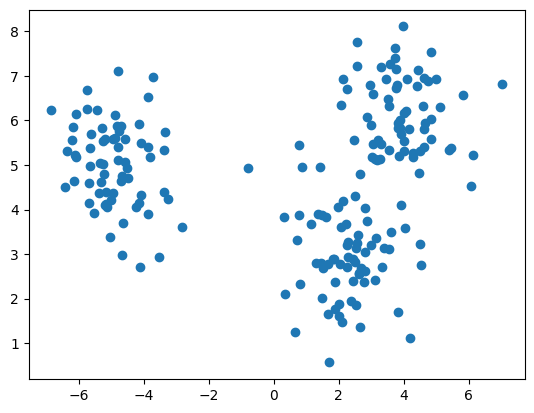

In [225]:
plt.scatter(X[:,0],X[:,1])

KMEANS CLASS
-

In [235]:
class KMean:
    def __init__(self,max_iter=100,n_clusters=2):
        self.n_cluster = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):
        # set centroid points
        index = random.sample(range(0,X.shape[0]),self.n_cluster)
        self.centroids = X[index];

        for i in range(self.max_iter):
            groups = self.assign_groups(X)
            old_centroids = self.centroids
            self.centroids = self.move_centroids(X,groups)
            # if(old_centroids == self.centroids).all():
            #     break

        return groups
               
             
    def assign_groups(self,X):
        groups = []
        distance = []

        for row in X:
            for cen in self.centroids:
                distance.append(np.sqrt(np.dot(row-cen,row-cen)))
            min_dis = min(distance)
            groups.append(distance.index(min_dis))
            distance.clear()
        
        return np.array(groups)

    def move_centroids(self,X,groups):
        new_centroids = []
        unique = np.unique(groups)
        for i in unique:
            new_centroids.append(X[groups == i].mean(axis=0))

        return new_centroids

    def get_centroids(self):
        return self.centroids
            

In [260]:
km = KMean(1000,3);
pred = km.fit_predict(X)
pred

array([1, 0, 0, 2, 0, 0, 2, 1, 0, 2, 1, 0, 0, 1, 0, 2, 0, 2, 0, 0, 2, 1,
       2, 1, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 1,
       2, 1, 2, 0, 1, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2,
       2, 1, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 1, 2, 2, 0, 0, 1, 1, 1, 2, 0,
       1, 0, 2, 2, 2, 1, 2, 0, 1, 2, 1, 1, 0, 1, 1, 2, 1, 1, 0, 1, 2, 2,
       2, 2, 0, 0, 2, 1, 0, 0, 2, 1, 1, 0, 2, 1, 0, 1, 2, 0, 1, 0, 0, 0,
       1, 1, 0, 2, 0, 1, 2, 0, 0, 1, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 2, 1,
       1, 0, 0, 1, 0, 2, 1, 2, 0, 2, 2, 1, 0, 1, 1, 2, 1, 0, 2, 1, 1, 0,
       2, 0, 1, 2, 2, 0, 0, 0, 2, 1, 2, 2, 1, 0, 2, 2, 1, 1, 2, 1, 1, 0,
       0, 2])

In [261]:
centroids = km.get_centroids()
centroids

[array([3.97210447, 6.16949141]),
 array([-4.91737781,  5.01122701]),
 array([2.2219222 , 2.99450785])]

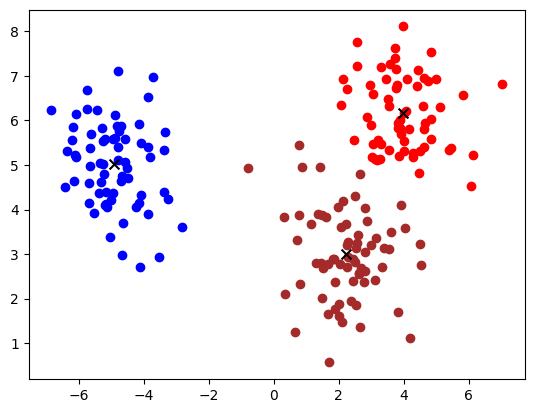

In [262]:
plt.scatter(X[pred==0,0],X[pred==0,1],color="red")
plt.scatter(centroids[0][0],centroids[0][1],marker="x",color="black",s=50)
plt.scatter(X[pred==1,0],X[pred==1,1],color="blue")
plt.scatter(centroids[1][0],centroids[1][1],marker="x",color="black",s=50)
plt.scatter(X[pred==2,0],X[pred==2,1],color="brown")
plt.scatter(centroids[2][0],centroids[2][1],marker="x",color="black",s=50)